<a href="https://colab.research.google.com/github/IvanSerem/agro-datascience/blob/main/ProyectoDS_ParteI_Seremczuk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Este proyecto trabaja con el dataset “Crop Yield”, que contiene más de 36.000 registros sobre distintos cultivos y condiciones agrícolas. La base de datos incluye información de 10 tipos de cultivos (trigo, maíz, arroz, soja, caña de azúcar, entre otros), 5 tipos de suelo, variables de nutrientes (N, P, K), pH del suelo, además de factores climáticos como temperatura, humedad y velocidad del viento. También incorpora un índice de calidad del suelo (Soil_Quality) y, lo más importante, el rendimiento de cada cultivo medido en quintales por hectárea, ya que es el termino que mas se adapta en el mundo de la agronomía.

Las fechas de este dataset abarcan desde el 2014 hasta el 2023.

El objetivo del análisis es entender qué factores hacen que una tierra sea más fructífera, combinando la mirada del suelo y el clima. Para eso se plantean preguntas simples pero clave: ¿qué cultivos rinden más en promedio?, ¿qué tipo de suelo es más productivo?, ¿qué tanto influyen la temperatura y la humedad?, ¿los nutrientes N, P y K marcan un punto de corte para suelos fértiles?

La exploración se realiza con un enfoque descriptivo y visual, utilizando análisis univariado, bivariado y multivariado. Con histogramas, boxplots, scatterplots y heatmaps buscamos detectar patrones y relaciones que expliquen por qué ciertos cultivos producen más en determinadas condiciones.

Como primer paso, se revisaron los datos y se comprobó que no existen valores faltantes, lo que permite trabajar directamente sobre la muestra. Luego, a través de gráficos y resúmenes numéricos, se identificaron zonas óptimas de productividad, por ejemplo: temperaturas moderadas cercanas a 20°C con humedades altas (75–80%) y suelos con buenos niveles de nitrógeno, fósforo y potasio.

Este análisis preliminar no pretende predecir todavía, pero sí dejar sentadas las bases para avanzar hacia modelos más sofisticados de machine learning, que permitan recomendar cultivos según el tipo de suelo y las condiciones climáticas.

Objetivo del Proyecto

Este análisis busca identificar patrones que permitan responder a la siguiente pregunta central: ¿es posible determinar, a partir de los valores del suelo y las condiciones climáticas, si una cosecha será fructífera?

El estudio servirá como base para construir, en etapas posteriores, modelos predictivos capaces de anticipar el rendimiento de un cultivo en función de su entorno. De esta manera, será posible tomar decisiones más informadas sobre qué sembrar, dónde sembrar y bajo qué condiciones, con el objetivo de optimizar la producción agrícola y reducir los riesgos asociados a la variabilidad del clima y la calidad del suelo.

Preguntas / Hipótesis de interés

1- ¿Qué cultivos son más productivos en promedio?

2- ¿Cuál es la proporción de productividad promedio por tipo de suelo?

3- ¿Existe una relación positiva entre la calidad del suelo y el rendimiento agrícola?

4- ¿Cómo varía la distribución del rendimiento según el tipo de cultivo??

5- ¿Qué combinación de temperatura y humedad maximiza el rendimiento agrícola?

6- ¿Qué relación tienen los nutrientes principales del suelo (N, P y K) con el rendimiento agrícola, y cuáles son los valores de referencia que marcan suelos fértiles?



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv('https://raw.githubusercontent.com/IvanSerem/agro-datascience/refs/heads/main/crop_yield_dataset.csv')
df.head()

,Date,Crop_Type,Soil_Type,Soil_pH,Temperature,Humidity,Wind_Speed,N,P,K,Crop_Yield,Soil_Quality
0,2014-01-01,Wheat,Peaty,5.50,9.440599,80.000000,10.956707,60.5,45.0,31.5,0.000000,22.833333
1,2014-01-01,Corn,Loamy,6.50,20.052576,79.947424,8.591577,84.0,66.0,50.0,104.871310,66.666667
2,2014-01-01,Rice,Peaty,5.50,12.143099,80.000000,7.227751,71.5,54.0,38.5,0.000000,27.333333
3,2014-01-01,Barley,Sandy,6.75,19.751848,80.000000,2.682683,50.0,40.0,30.0,58.939796,35.000000
4,2014-01-01,Soybean,Peaty,5.50,16.110395,80.000000,7.696070,49.5,45.0,38.5,32.970413,22.166667


In [ ]:
missing = df.isna().sum().sort_values(ascending=False)
missing[missing > 0]

,0


Top 10 cultivos por rendimiento promedio:
   Crop_Type  Crop_Yield
0     Cotton   29.208710
1  Sugarcane   28.694864
2       Rice   28.688229
3       Corn   28.330560
4  Sunflower   27.498513
5     Potato   26.213347
6    Soybean   25.932047
7      Wheat   25.871497
8     Barley   25.552846
9     Tomato   22.794184


/tmp/ipython-input-1155146281.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_crops, x="Crop_Yield", y="Crop_Type", palette="viridis")


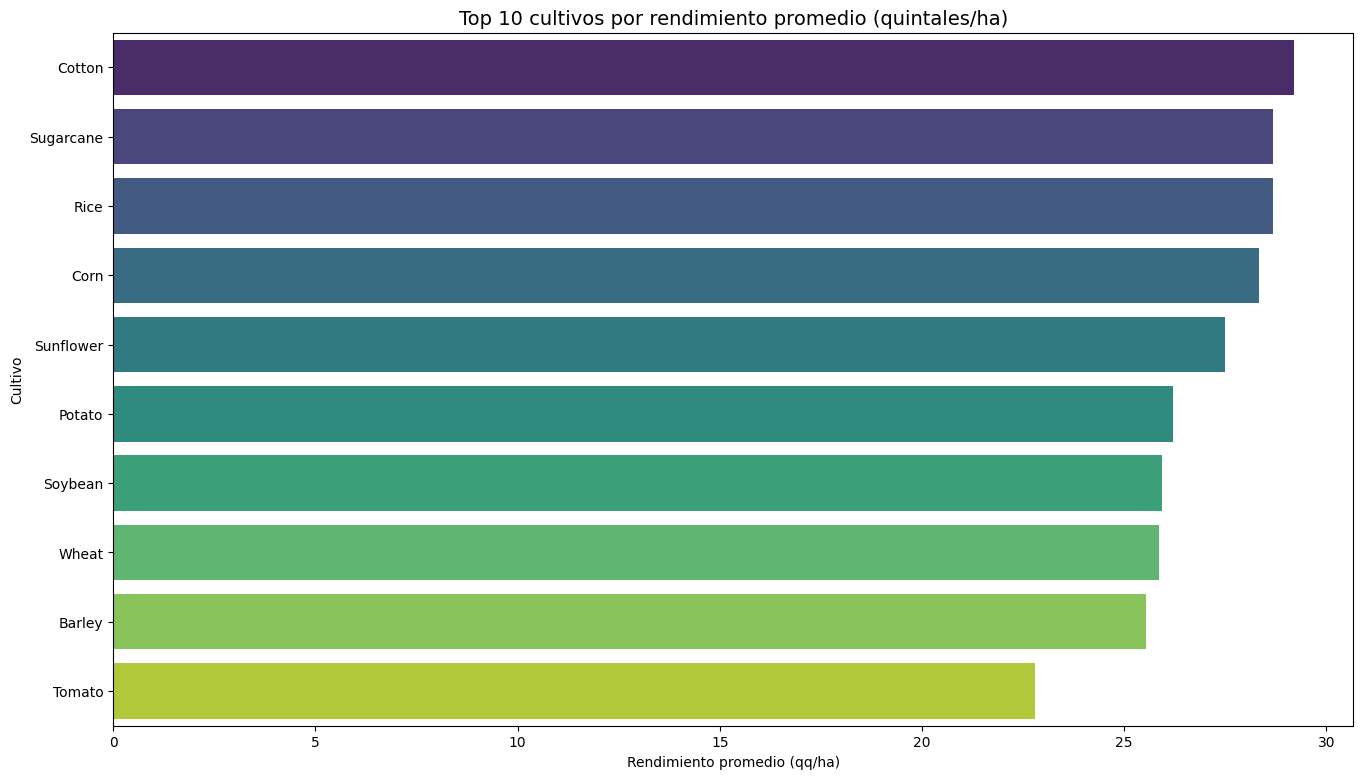

In [ ]:
# Top 10 cultivos por rendimiento promedio
top_crops = (
    df.groupby("Crop_Type")["Crop_Yield"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

print("Top 10 cultivos por rendimiento promedio:")
print(top_crops)

# Gráfico
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
sns.barplot(data=top_crops, x="Crop_Yield", y="Crop_Type", palette="viridis")
plt.title("Top 10 cultivos por rendimiento promedio (quintales/ha)", fontsize=14)
plt.xlabel("Rendimiento promedio (qq/ha)")
plt.ylabel("Cultivo")
plt.show()


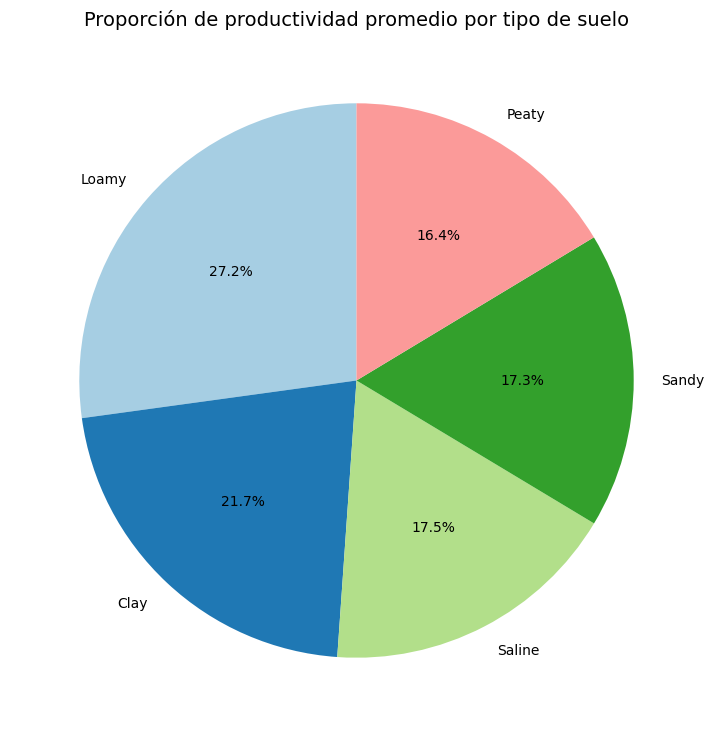

In [ ]:
import matplotlib.pyplot as plt

# Rendimiento promedio por tipo de suelo
soil_yield = (
    df.groupby("Soil_Type")["Crop_Yield"]
    .mean()
    .sort_values(ascending=False)
)

# Gráfico de torta
plt.figure(figsize=(16,9))
plt.pie(
    soil_yield,
    labels=soil_yield.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Paired.colors
)
plt.title("Proporción de productividad promedio por tipo de suelo", fontsize=14)
plt.show()


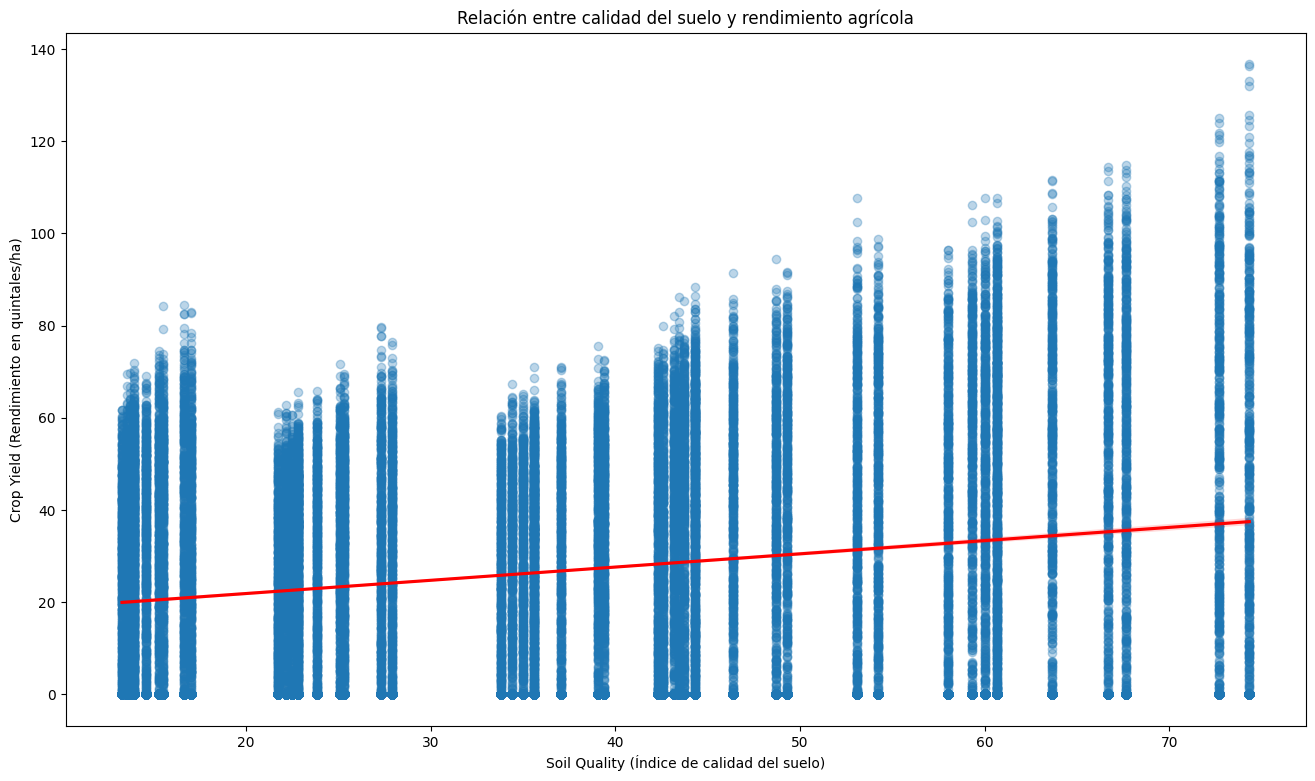

Correlación Soil_Quality ↔ Crop_Yield: 0.197


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Scatterplot con línea de regresión
plt.figure(figsize=(16,9))
sns.regplot(
    data=df,
    x="Soil_Quality",
    y="Crop_Yield",
    scatter_kws={"alpha":0.3},   # puntos más transparentes
    line_kws={"color":"red"}     # línea de tendencia en rojo
)
plt.title("Relación entre calidad del suelo y rendimiento agrícola")
plt.xlabel("Soil Quality (Índice de calidad del suelo)")
plt.ylabel("Crop Yield (Rendimiento en quintales/ha)")
plt.show()

# Calcular la correlación
corr = df["Soil_Quality"].corr(df["Crop_Yield"])
print(f"Correlación Soil_Quality ↔ Crop_Yield: {corr:.3f}")


/tmp/ipython-input-2960593950.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


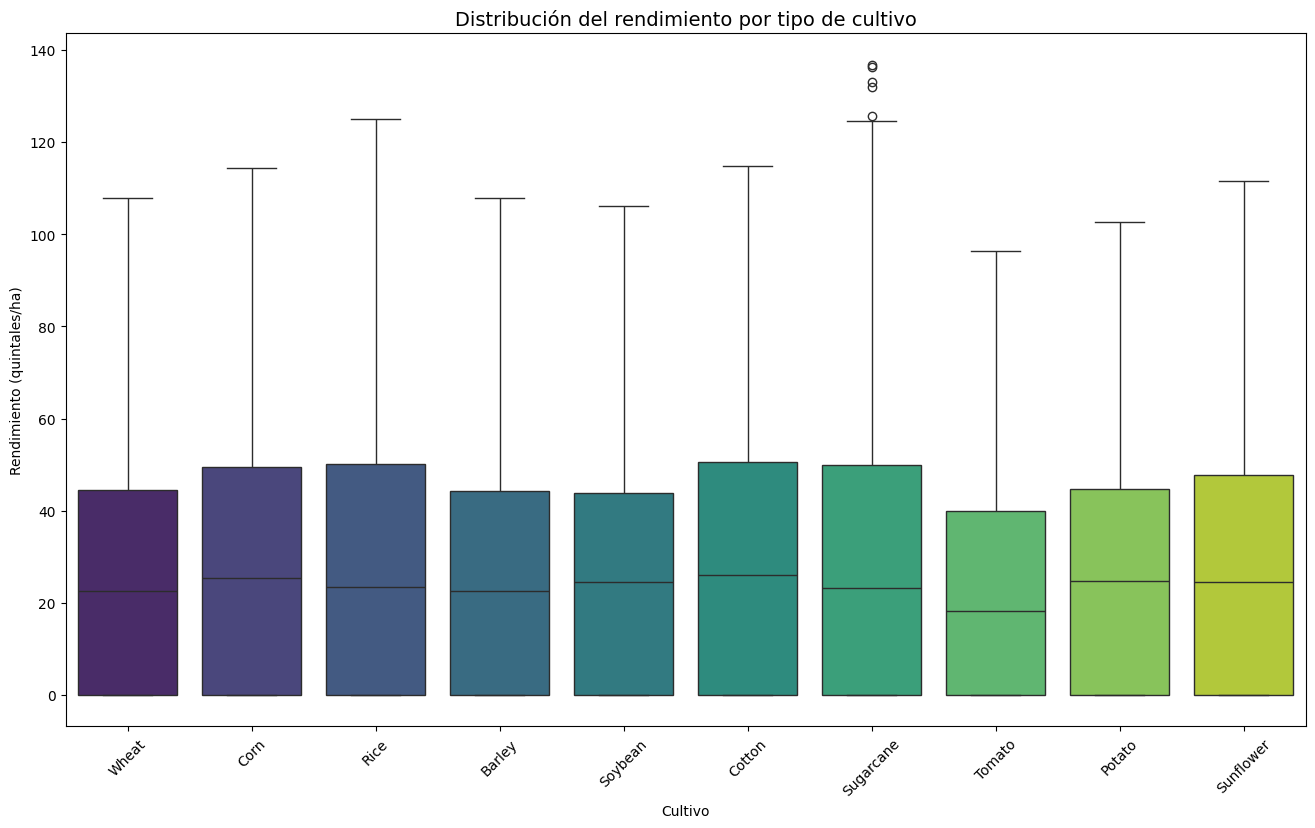

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,9))
sns.boxplot(
    data=df,
    x="Crop_Type",
    y="Crop_Yield",
    palette="viridis"  # paleta de colores bonita
)
plt.title("Distribución del rendimiento por tipo de cultivo", fontsize=14)
plt.xlabel("Cultivo")
plt.ylabel("Rendimiento (quintales/ha)")
plt.xticks(rotation=45)
plt.show()


/tmp/ipython-input-1717640932.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = df.pivot_table(


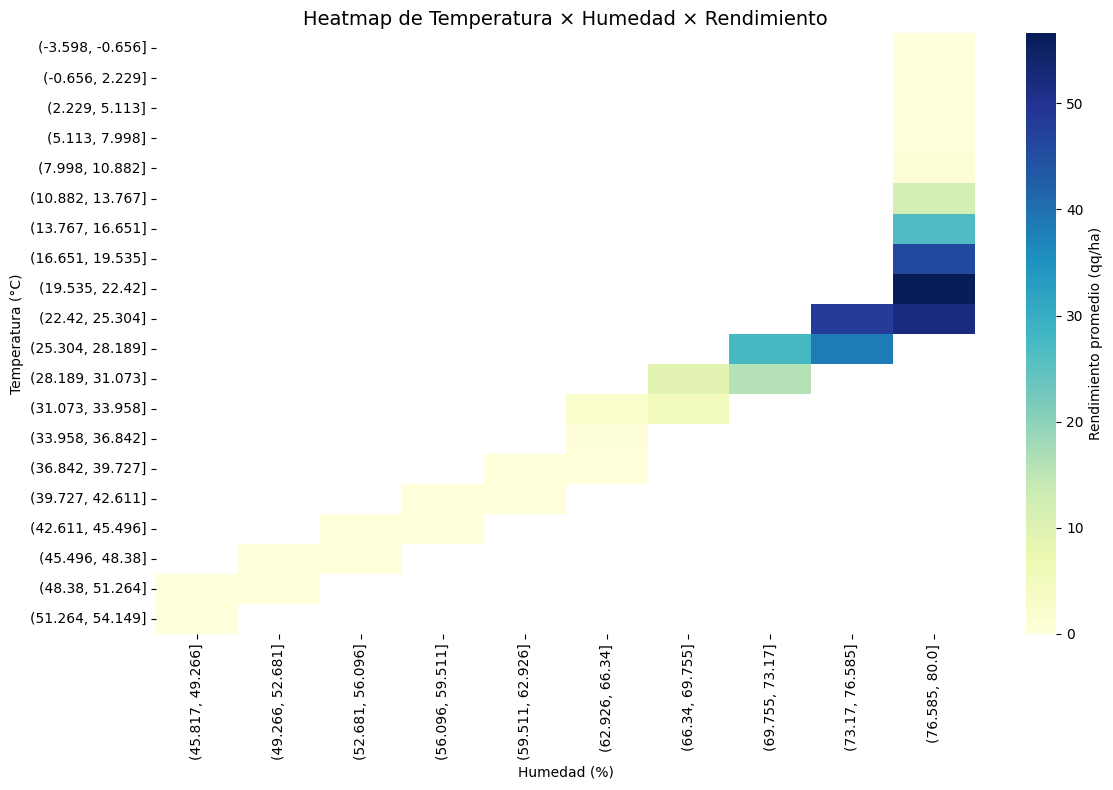

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Crear tabla pivote: promedio de rendimiento según temperatura y humedad
pivot_table = df.pivot_table(
    values="Crop_Yield",
    index=pd.cut(df["Temperature"], bins=20),   # dividimos la temperatura en 20 rangos
    columns=pd.cut(df["Humidity"], bins=10),    # dividimos la humedad en 10 rangos
    aggfunc="mean"
)

# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(
    pivot_table,
    cmap="YlGnBu",  # paleta de colores
    cbar_kws={'label': 'Rendimiento promedio (qq/ha)'}
)
plt.title("Heatmap de Temperatura × Humedad × Rendimiento", fontsize=14)
plt.xlabel("Humedad (%)")
plt.ylabel("Temperatura (°C)")
plt.tight_layout()
plt.show()


Media y Mediana de N, P y K:


,Media,Mediana
N,66.011035,65.0
P,53.014006,54.0
K,42.018250,42.0



Correlación de N, P y K con el rendimiento (Crop_Yield):


,Crop_Yield
N,0.143744
P,0.166614
K,0.155379


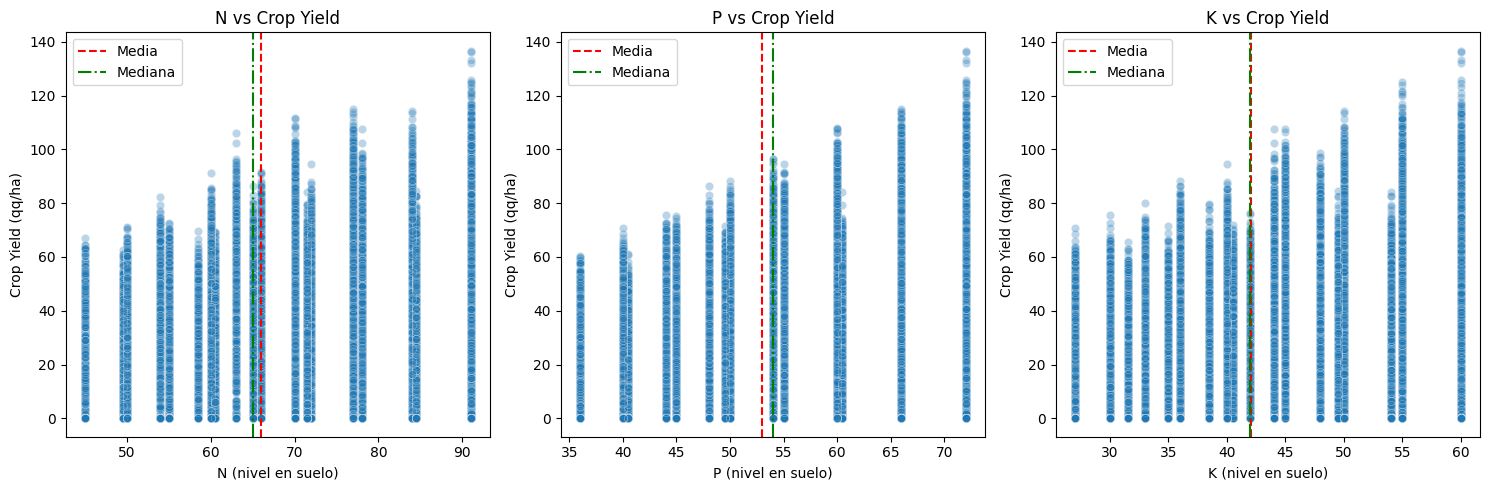

In [ ]:
import pandas as pd

# --- Estadísticos descriptivos de N, P, K ---
nutrients_stats = df[["N", "P", "K"]].agg(["mean", "median"]).T
nutrients_stats.columns = ["Media", "Mediana"]
print("Media y Mediana de N, P y K:")
display(nutrients_stats)

# --- Correlaciones con el rendimiento (Crop_Yield) ---
correlations = df[["N", "P", "K", "Crop_Yield"]].corr()["Crop_Yield"].drop("Crop_Yield")
print("\nCorrelación de N, P y K con el rendimiento (Crop_Yield):")
display(correlations)

# --- Comparación visual: distribuciones vs rendimiento ---
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i, nutrient in enumerate(["N", "P", "K"], 1):
    plt.subplot(1, 3, i)
    sns.scatterplot(data=df, x=nutrient, y="Crop_Yield", alpha=0.3)
    plt.axvline(df[nutrient].mean(), color="red", linestyle="--", label="Media")
    plt.axvline(df[nutrient].median(), color="green", linestyle="-.", label="Mediana")
    plt.title(f"{nutrient} vs Crop Yield")
    plt.xlabel(f"{nutrient} (nivel en suelo)")
    plt.ylabel("Crop Yield (qq/ha)")
    plt.legend()

plt.tight_layout()
plt.show()


Conclusiones Preliminares

-Los cultivos más productivos en promedio fueron algodón, caña de azúcar y arroz, mientras que tomate y cebada se ubicaron en el extremo inferior.

-Entre los tipos de suelo, el Loamy y Clay concentran la mayor proporción de productividad, confirmando que son los más fértiles en este dataset.

-Existe una relación positiva entre el índice de calidad del suelo y el rendimiento: a mayor calidad, mayor producción, aunque con variabilidad según el cultivo.

-La distribución por cultivo muestra diferencias importantes en estabilidad: mientras que caña de azúcar presenta altos rendimientos con variabilidad, cultivos como trigo o tomate son más consistentes pero con menores valores.

-En cuanto a las condiciones climáticas, el heatmap de temperatura y humedad deja claro que el punto óptimo se alcanza en temperaturas moderadas (≈20°C) combinadas con humedades altas (≈76–80%).

-Los nutrientes del suelo (N=65, P=54, K=42 como valores de referencia en mediana) actúan como umbrales de fertilidad: suelos con valores iguales o superiores tienden a generar mejores cosechas.

Los análisis confirman que la productividad agrícola no depende de un solo factor, sino de la combinación entre el tipo de cultivo, el suelo (su fertilidad y calidad) y el clima (temperatura + humedad). Estas observaciones iniciales abren la puerta a desarrollar un modelo predictivo que pueda anticipar el rendimiento en función de estas condiciones.